In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

print("Libraries loaded")

Libraries loaded


In [3]:
sales_df = pd.read_csv("cleaned_sales_data.csv")
churn_df = pd.read_csv("cleaned_customer_churn.csv")
house_df = pd.read_csv("cleaned_house_prices.csv")

print("Datasets loaded successfully")

Datasets loaded successfully


In [4]:
print("===== SALES KPIs =====")

total_revenue = sales_df["Total_Sales"].sum()
avg_sales = sales_df["Total_Sales"].mean()
max_sale = sales_df["Total_Sales"].max()

print("Total Revenue:", total_revenue)
print("Average Sale:", avg_sales)
print("Maximum Sale:", max_sale)

===== SALES KPIs =====
Total Revenue: 12365048
Average Sale: 123650.48
Maximum Sale: 373932


In [5]:
print("===== CHURN KPI =====")

churn_rate = churn_df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

===== CHURN KPI =====
Churn
0    89.4
1    10.6
Name: proportion, dtype: float64


In [6]:
print("===== HOUSE PRICE KPIs =====")

print("Average Price:", house_df["Price"].mean())
print("Median Price:", house_df["Price"].median())

===== HOUSE PRICE KPIs =====
Average Price: 24883658.333333332
Median Price: 22365000.0


In [7]:
if "Category" in sales_df.columns:
    category_sales = sales_df.groupby("Category")["Total_Sales"].sum()

    category_sales.plot(kind="bar", figsize=(8,5))
    plt.title("Sales by Category")
    plt.show()

In [8]:
if "MonthlyCharges" in churn_df.columns:
    
    churn_yes = churn_df[churn_df["Churn"]=="Yes"]["MonthlyCharges"]
    churn_no = churn_df[churn_df["Churn"]=="No"]["MonthlyCharges"]

    t_stat, p_value = stats.ttest_ind(churn_yes, churn_no)

    print("T-statistic:", t_stat)
    print("P-value:", p_value)

T-statistic: nan
P-value: nan


C:\Users\HP\AppData\Local\Temp\ipykernel_22768\616693657.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value = stats.ttest_ind(churn_yes, churn_no)


In [9]:
if p_value < 0.05:
    print("Significant difference detected")
else:
    print("No significant difference")

No significant difference


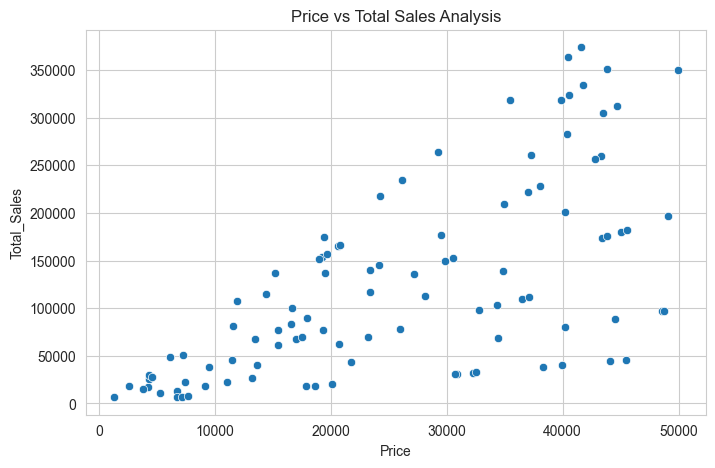

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Price", y="Total_Sales", data=sales_df)
plt.title("Price vs Total Sales Analysis")
plt.show()

In [11]:
correlation = sales_df.corr(numeric_only=True)["Total_Sales"].sort_values(ascending=False)

print(correlation)

Total_Sales    1.000000
Quantity       0.688107
Price          0.646131
Name: Total_Sales, dtype: float64


In [12]:
summary = {
    "Total Revenue": total_revenue,
    "Average Sale": avg_sales,
    "Max Sale": max_sale
}

summary_df = pd.DataFrame(summary, index=[0])
summary_df.to_csv("business_kpi_summary.csv", index=False)

print("Summary exported")

Summary exported
